# Scenario API OpenABM Adapter Test
This notebook validates the first OpenABM adapter layer end-to-end.

## A. Imports

In [1]:
import sys
from pathlib import Path

# Locate the repository root by searching for extensions/scenario_api
cwd = Path.cwd().resolve()
repo_root = next((p for p in [cwd, *cwd.parents] if (p / 'extensions' / 'scenario_api').exists()), None)
if repo_root is None:
    raise RuntimeError('Could not locate extensions/scenario_api from current working directory')

extensions_dir = repo_root / 'extensions'
if str(extensions_dir) not in sys.path:
    sys.path.insert(0, str(extensions_dir))

from scenario_api import *


## B. Create Scenario

In [2]:
block = create_block(
    name="base_block",
    params={"end_time": 40, "test_on_traced": 0}
)

intervention = create_parameter_intervention(
    name="turn_on_testing",
    start=5,
    end=10,
    params={"test_on_symptoms": 1},
)

networks = [
    create_network_spec("households", "household", {"population_size": 1000}),
    create_network_spec("work", "activity_structured", {"mean_contacts": 8, "activation_prob": 0.5}),
    create_network_spec("community", "activity_random", {"mean_contacts": 3}),
]

scenario = create_scenario(
    name="openabm_adapter_demo",
    base_params={"end_time": 40, "test_on_symptoms": 0},
    blocks=[block],
    interventions=[intervention],
    network_specs=networks,
)
print(scenario)


Scenario(name='openabm_adapter_demo', base_params={'end_time': 40, 'test_on_symptoms': 0}, blocks=[ParameterBlock(name='base_block', params={'end_time': 40, 'test_on_traced': 0}, metadata={})], network_specs=[NetworkSpec(name='households', kind='household', config={'population_size': 1000}, metadata={}), NetworkSpec(name='work', kind='activity_structured', config={'mean_contacts': 8, 'activation_prob': 0.5}, metadata={}), NetworkSpec(name='community', kind='activity_random', config={'mean_contacts': 3}, metadata={})], events=[], interventions=[ParameterIntervention(name='turn_on_testing', start=5, end=10, metadata={}, params={'test_on_symptoms': 1})], parent=None, metadata={})


## C. Resolve Scenario

In [3]:
resolved = resolve_scenario(scenario)
print("Resolved params:", resolved.resolved_params)
print("Network specs:")
for ns in resolved.network_specs:
    print(ns)
print("Events by time:")
for t in sorted(resolved.events_by_time):
    print(t, resolved.events_by_time[t])


Resolved params: {'end_time': 40, 'test_on_symptoms': 0, 'test_on_traced': 0}
Network specs:
NetworkSpec(name='households', kind='household', config={'population_size': 1000}, metadata={})
NetworkSpec(name='work', kind='activity_structured', config={'mean_contacts': 8, 'activation_prob': 0.5}, metadata={})
NetworkSpec(name='community', kind='activity_random', config={'mean_contacts': 3}, metadata={})
Events by time:
5 [TimelineEvent(time=5, action='set', target='test_on_symptoms', value=1, event_type='soft', metadata={'intervention': 'turn_on_testing', 'phase': 'start'})]
10 [TimelineEvent(time=10, action='set', target='test_on_symptoms', value=0, event_type='soft', metadata={'intervention': 'turn_on_testing', 'phase': 'end_restore'})]


## D. Adapter Translation Inspection

In [4]:
openabm_params = resolved_params_to_openabm_params(resolved.resolved_params)
openabm_network_cfg = network_specs_to_openabm_config(resolved.network_specs)

print("OpenABM params translation:")
print(openabm_params)
print("\nOpenABM network config translation:")
print(openabm_network_cfg)


OpenABM params translation:
{'end_time': 40, 'test_on_symptoms': 0, 'test_on_traced': 0}

OpenABM network config translation:
{'household': [{'name': 'households', 'kind': 'household', 'config': {'population_size': 1000}, 'metadata': {}}], 'occupation_like': [{'name': 'work', 'kind': 'activity_structured', 'config': {'mean_contacts': 8, 'activation_prob': 0.5}, 'metadata': {}}], 'random_like': [{'name': 'community', 'kind': 'activity_random', 'config': {'mean_contacts': 3}, 'metadata': {}}]}


## E/F. Create OpenABM-backed Model and Run Short Simulation (with fallback)

In [5]:
# Run against the real OpenABM adapter path.
run_openabm = True

if is_openabm_available() and run_openabm:
    model_factory, result_extractor = create_openabm_runner_components(resolved)
    result = run_scenario(
        resolved,
        steps=15,
        model_factory=model_factory,
        result_extractor=result_extractor,
    )
    run_mode = "openabm"
    print("OpenABM adapter run succeeded")
else:
    if not is_openabm_available():
        print("OpenABM is not available in this environment. Running dummy fallback.")
    else:
        print("OpenABM available but run_openabm=False. Using dummy fallback.")
    result = run_scenario(resolved, steps=15)
    run_mode = "dummy"

print("Run mode:", run_mode)
print("Result keys:", list(result.raw_outputs.keys()))


/home/ubuntu/OpenABM-Covid19/src/COVID19/model.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


OpenABM adapter run succeeded
Run mode: openabm
Result keys: ['cases', 'infected', 'deaths']


## G. Convert to TimeSeries and Plot

TimeSeries(name='openabm_adapter_demo_cases', times=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14], values=[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 3.0, 6.0, 8.0, 16.0, 16.0, 16.0, 16.0], variable='cases', source_type='simulation', source_name='openabm_adapter_demo', metadata={})


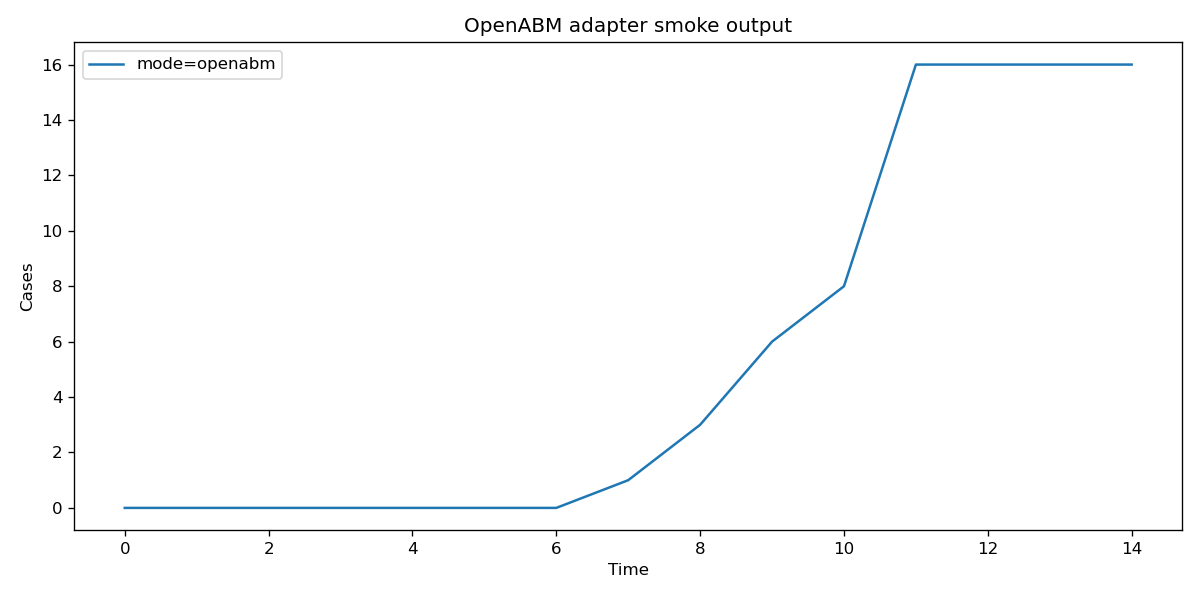

In [6]:
ts = result_to_timeseries(result, "cases")
print(ts)

import io
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from IPython.display import Image, display

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(ts.times, ts.values, label=f"mode={run_mode}")
ax.set_xlabel('Time')
ax.set_ylabel('Cases')
ax.set_title('OpenABM adapter smoke output')
ax.legend()
fig.tight_layout()

buf = io.BytesIO()
fig.savefig(buf, format='png', dpi=120)
plt.close(fig)
buf.seek(0)
display(Image(data=buf.read()))
